# YOLOv11 — COCO 2017 | Skripsi ELIOR
**Sesi v11** | 30 epoch | dual-T4 | nano | full COCO (118K)

Pipeline: Install → Path → Load → EDA → Convert → Symlink → YAML → Patch → Train → Eval → Zip+Link

> **Download tiap checkpoint** lewat FileLink. Kalau link mati (Kaggle kadang gitu): **Save Version → tab Output**.

## 0 — INSTALL & IMPORTS

In [1]:
!pip install ultralytics supervision --quiet

import os, json, random, time, gc, warnings, glob, shutil, zipfile
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime
from IPython.display import FileLink, display
import torch
from ultralytics import YOLO

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.backends.cudnn.benchmark = True

print(f"PyTorch : {torch.__version__}")
N_GPU = torch.cuda.device_count()
print(f"GPU cnt : {N_GPU}")
for i in range(N_GPU):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)} "
          f"({torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB)")

# auto device + auto workers (bottleneck I/O symlink -> workers penting)
import psutil
DEVICE  = list(range(N_GPU)) if N_GPU > 1 else 0
WORKERS = min(psutil.cpu_count() or 4, 8)
print(f"DEVICE  : {DEVICE}")
print(f"WORKERS : {WORKERS}  (cpu_count={psutil.cpu_count()})")
print(f"RAM free: {psutil.virtual_memory().available/1e9:.1f} GB")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch : 2.10.0+cu128
GPU cnt : 2
  GPU 0: Tesla T4 (15.6 GB)
  GPU 1: Tesla T4 (15.6 GB)
DEVICE  : [0, 1]
WORKERS : 4  (cpu_count=4)
RAM free: 31.8 GB


## 1 — HELPER: zip + download link
Dipanggil tiap checkpoint. Coba FileLink dulu, fallback ke instruksi commit.

In [4]:
OUT = Path('/kaggle/working')

def zip_and_link(patterns, zip_name, label=""):
    files = []
    for pat in patterns:
        files += sorted(OUT.glob(pat))
    files = [f for f in dict.fromkeys(files) if f.is_file() and f.suffix != '.zip']
    if not files:
        print(f"[{label}] Tidak ada file untuk di-zip ({patterns})"); return None
    zp = OUT / zip_name
    with zipfile.ZipFile(zp, 'w', zipfile.ZIP_DEFLATED) as zf:
        for f in files: zf.write(f, f.name)
    print(f"\n{'='*55}\n  [{label}] ZIP: {zp.name} "
          f"({zp.stat().st_size/1e6:.1f} MB) | {len(files)} file\n{'='*55}")
    for f in files: print(f"   + {f.name}")
    print("\n  >> Klik link (kalau muncul):")
    try: display(FileLink(str(zp)))
    except Exception as e: print(f"   FileLink err: {e}")
    print(f"  >> Link mati? Save Version -> Output tab -> {zp.name}")
    return zp

## 2 — PATH CONFIG

In [5]:
COCO_ROOT = Path('/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017')
TRAIN_IMG = COCO_ROOT / 'train2017'
VAL_IMG   = COCO_ROOT / 'val2017'
TEST_IMG  = COCO_ROOT / 'test2017'
ANN_TRAIN = COCO_ROOT / 'annotations/instances_train2017.json'
ANN_VAL   = COCO_ROOT / 'annotations/instances_val2017.json'
print("Path check:")
for p in [TRAIN_IMG, VAL_IMG, TEST_IMG, ANN_TRAIN, ANN_VAL]:
    print(f"  {'OK ' if p.exists() else 'MISSING'} {p}")

Path check:
  OK  /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017
  OK  /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017
  OK  /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/test2017
  OK  /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_train2017.json
  OK  /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_val2017.json


## 3 — LOAD ANNOTATIONS

In [6]:
print("Loading annotations...")
with open(ANN_TRAIN) as f: ann_train = json.load(f)
with open(ANN_VAL)   as f: ann_val   = json.load(f)
TRAIN_IMGS = ann_train['images'];  VAL_IMGS = ann_val['images']
TRAIN_ANNS = ann_train['annotations']; VAL_ANNS = ann_val['annotations']
CATEGORIES = {c['id']: c['name'] for c in ann_train['categories']}
CAT_NAMES  = [c['name'] for c in sorted(ann_train['categories'], key=lambda x: x['id'])]
print(f"  Train images : {len(TRAIN_IMGS):>8,}")
print(f"  Val   images : {len(VAL_IMGS):>8,}")
print(f"  Categories   : {len(CATEGORIES):>8}")

Loading annotations...
  Train images :  118,287
  Val   images :    5,000
  Categories   :       80


## 4 — EDA (Exploratory Data Analysis)
Semua plot disimpan ke `/kaggle/working` → masuk ke ZIP checkpoint pre-training.

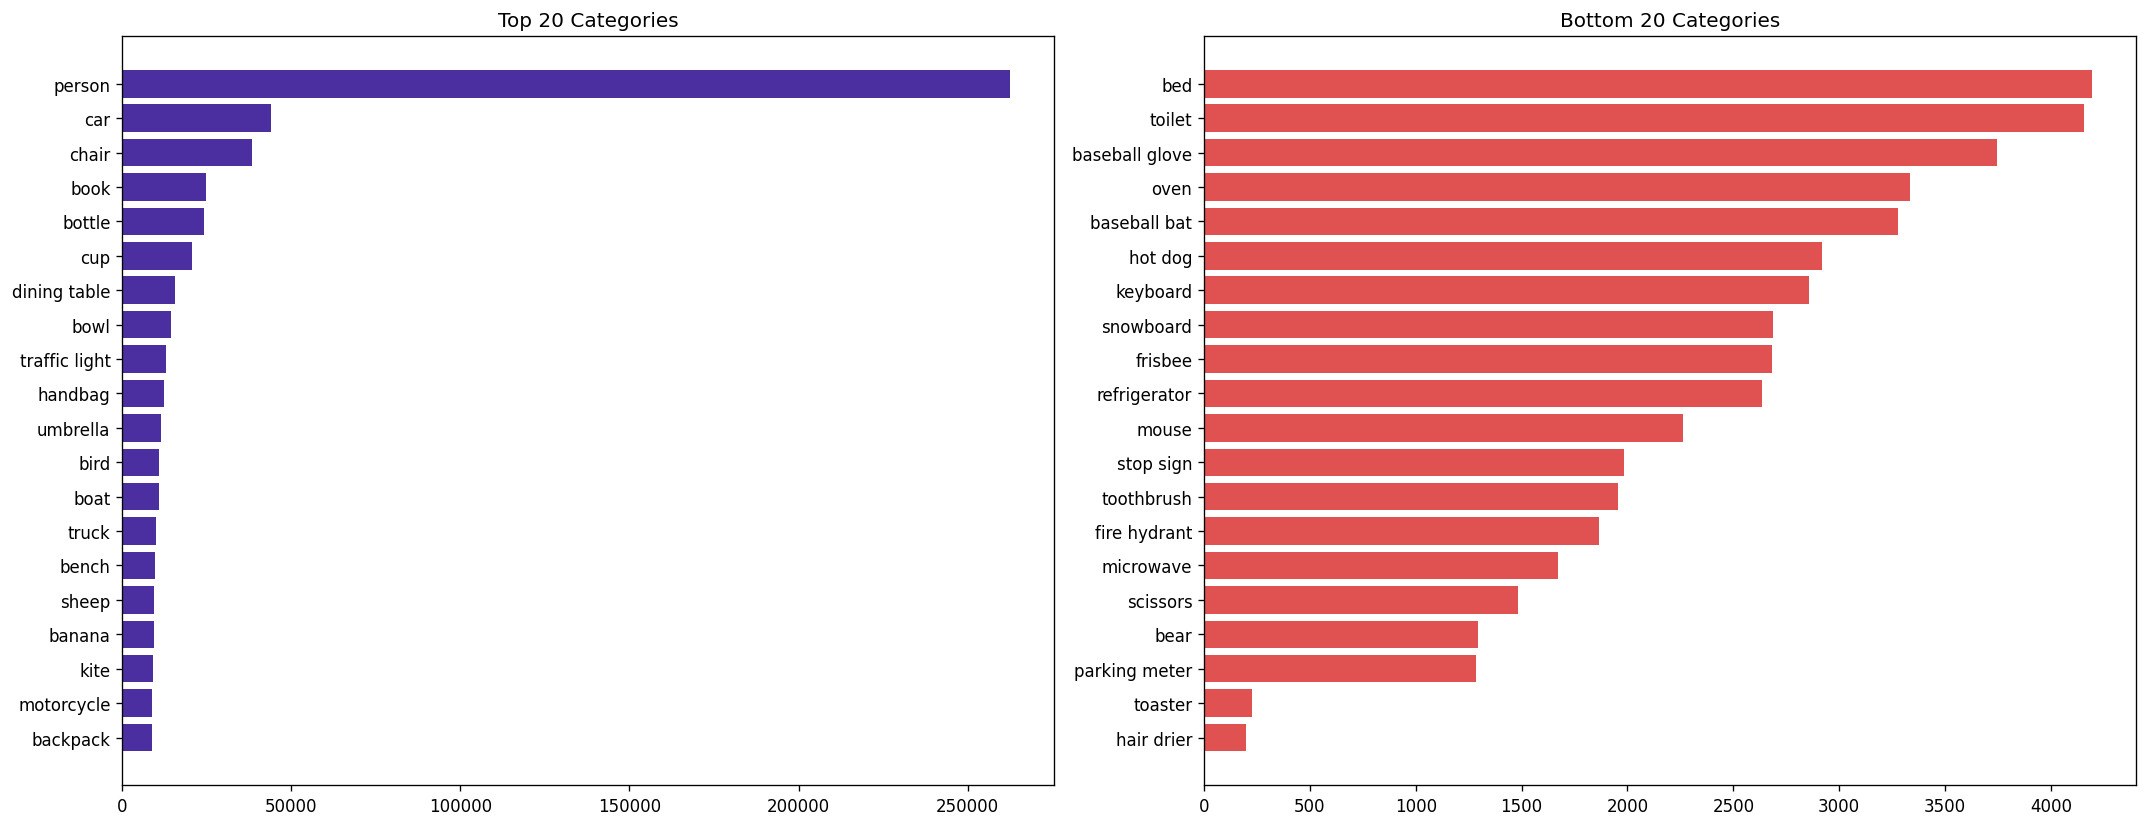

Imbalance: 1326x (person vs hair drier)


In [7]:
# 4A Category distribution
cat_counts = Counter(a['category_id'] for a in TRAIN_ANNS)
cat_df = pd.DataFrame([{'category':CATEGORIES[k],'count':v,'cat_id':k}
                       for k,v in cat_counts.items()]
                     ).sort_values('count',ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(1,2,figsize=(18,7))
ax[0].barh(cat_df['category'][:20], cat_df['count'][:20], color='#4B2FA0')
ax[0].set_title('Top 20 Categories'); ax[0].invert_yaxis()
ax[1].barh(cat_df['category'][-20:], cat_df['count'][-20:], color='#E05252')
ax[1].set_title('Bottom 20 Categories'); ax[1].invert_yaxis()
plt.tight_layout(); plt.savefig(OUT/'eda_01_category.png',dpi=120); plt.show()
print(f"Imbalance: {cat_df.iloc[0]['count']/cat_df.iloc[-1]['count']:.0f}x "
      f"({cat_df.iloc[0]['category']} vs {cat_df.iloc[-1]['category']})")

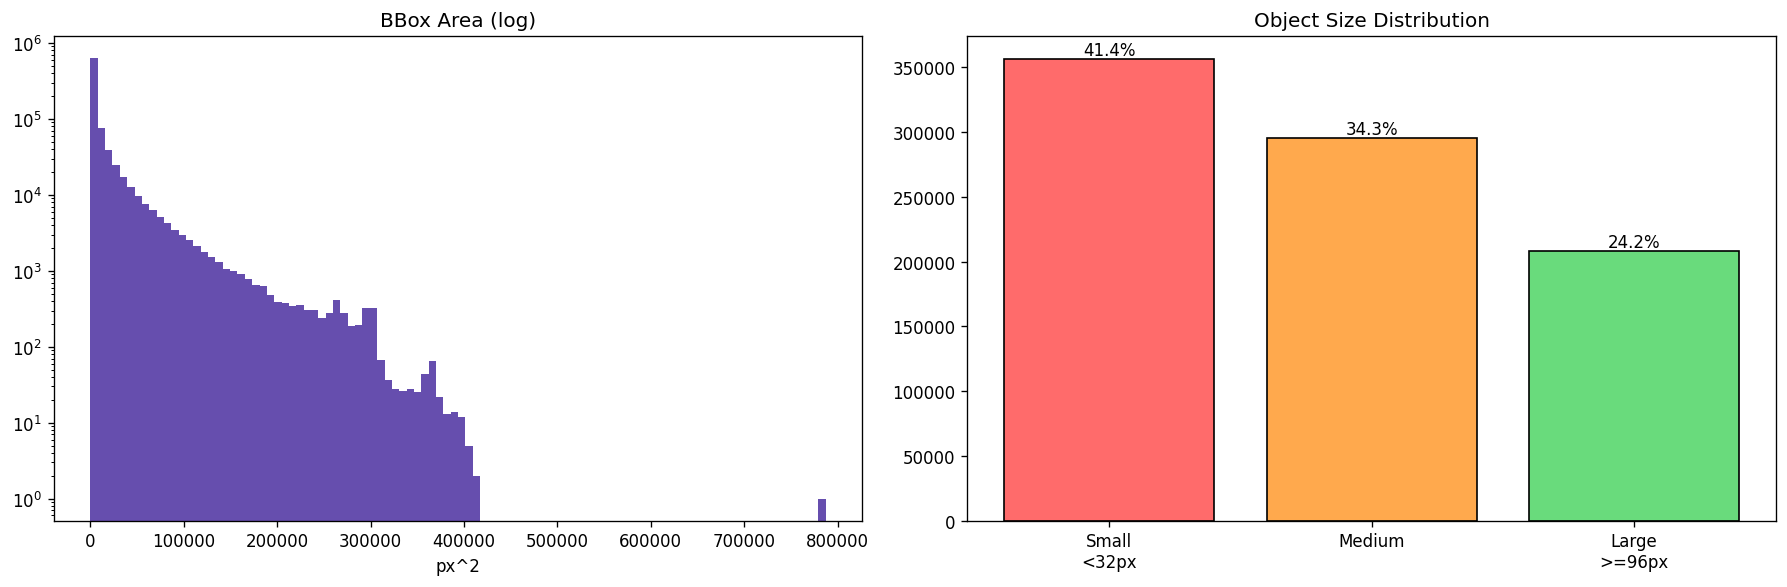

Small 41.4% | Medium 34.3% | Large 24.2%


In [9]:
# 4B Object size (penting: COCO banyak objek kecil = tantangan deteksi)
areas = [a['area'] for a in TRAIN_ANNS]
S = sum(1 for a in areas if a < 32**2)
M = sum(1 for a in areas if 32**2 <= a < 96**2)
L = sum(1 for a in areas if a >= 96**2); T = len(areas)
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].hist(areas, bins=100, color='#4B2FA0', log=True, alpha=0.85)
ax[0].set_title('BBox Area (log)'); ax[0].set_xlabel('px^2')
b = ax[1].bar(['Small\n<32px','Medium','Large\n>=96px'],[S,M,L],
              color=['#ff6b6b','#ffa94d','#69db7c'], edgecolor='black')
ax[1].set_title('Object Size Distribution')
for bar,c in zip(b,[S,M,L]):
    ax[1].text(bar.get_x()+bar.get_width()/2, bar.get_height(),
               f'{c/T*100:.1f}%', ha='center', va='bottom')
plt.tight_layout(); plt.savefig(OUT/'eda_02_objsize.png',dpi=120); plt.show()
print(f"Small {S/T*100:.1f}% | Medium {M/T*100:.1f}% | Large {L/T*100:.1f}%")

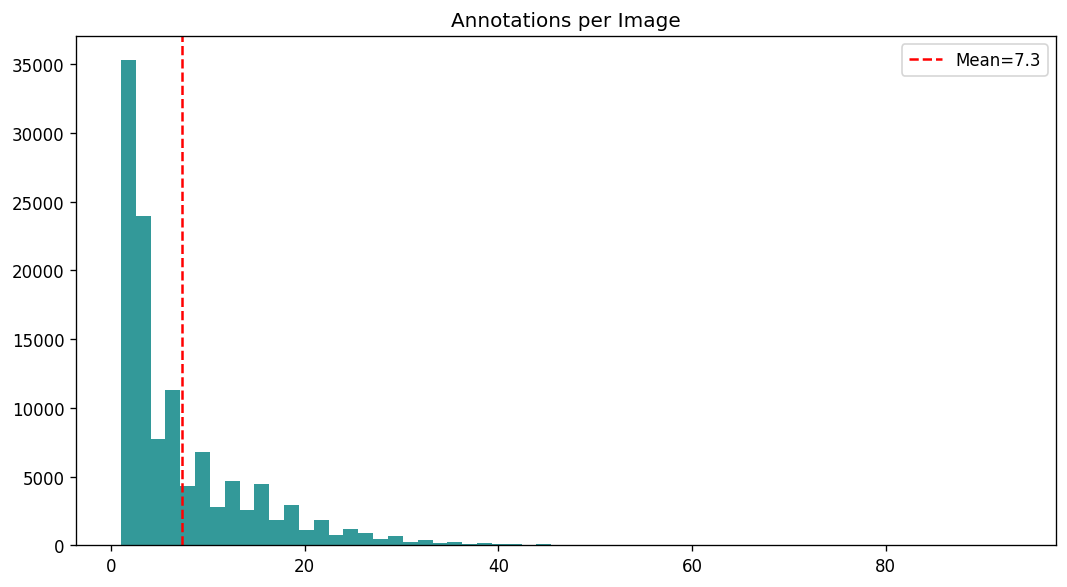

Mean 7.33 | Median 4 | Max 93


In [10]:
# 4C Annotations per image
api = Counter(a['image_id'] for a in TRAIN_ANNS); counts=list(api.values())
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(counts, bins=60, color='teal', alpha=0.8)
ax.axvline(np.mean(counts), color='red', ls='--', label=f'Mean={np.mean(counts):.1f}')
ax.set_title('Annotations per Image'); ax.legend()
plt.tight_layout(); plt.savefig(OUT/'eda_03_annperimg.png',dpi=120); plt.show()
print(f"Mean {np.mean(counts):.2f} | Median {np.median(counts):.0f} | Max {max(counts)}")

In [11]:
# 4D EDA summary + CHECKPOINT 1 (pre-training zip)
print("="*50)
print(f"  Train imgs: {len(TRAIN_IMGS):,} | Val imgs: {len(VAL_IMGS):,}")
print(f"  Classes: {len(CATEGORIES)} | Anns: {len(TRAIN_ANNS):,}")
print(f"  Small objs: {S/T*100:.1f}% (tantangan deteksi objek kecil)")
print("="*50)
zip_and_link(['eda_*.png'], 'CP1_eda_pretraining.zip', label='CP1 PRE-TRAINING')

  Train imgs: 118,287 | Val imgs: 5,000
  Classes: 80 | Anns: 860,001
  Small objs: 41.4% (tantangan deteksi objek kecil)

  [CP1 PRE-TRAINING] ZIP: CP1_eda_pretraining.zip (0.1 MB) | 3 file
   + eda_01_category.png
   + eda_02_objsize.png
   + eda_03_annperimg.png

  >> Klik link (kalau muncul):


/kaggle/working/CP1_eda_pretraining.zip

  >> Link mati? Save Version -> Output tab -> CP1_eda_pretraining.zip


PosixPath('/kaggle/working/CP1_eda_pretraining.zip')

## 5 — CONVERT COCO→YOLO + SYMLINK
Auto-detect: kalau label & symlink sudah ada (sisa sesi lalu), **skip** biar hemat ~15 menit.

In [12]:
# 5A Convert COCO JSON -> YOLO txt (auto-skip kalau sudah ada)
def coco2yolo(ann_json, label_dir):
    Path(label_dir).mkdir(parents=True, exist_ok=True)
    with open(ann_json) as f: data = json.load(f)
    info = {im['id']: im for im in data['images']}
    by_img = defaultdict(list)
    for a in data['annotations']:
        if a.get('iscrowd',0): continue
        by_img[a['image_id']].append(a)
    cat_ids = sorted(c['id'] for c in data['categories'])
    cmap = {cid:i for i,cid in enumerate(cat_ids)}
    n=0
    for iid, anns in by_img.items():
        im = info[iid]; W,H = im['width'], im['height']
        stem = Path(im['file_name']).stem
        lines=[]
        for a in anns:
            x,y,w,h = a['bbox']
            lines.append(f"{cmap[a['category_id']]} {(x+w/2)/W:.6f} {(y+h/2)/H:.6f} {w/W:.6f} {h/H:.6f}")
        with open(f"{label_dir}/{stem}.txt",'w') as f: f.write('\n'.join(lines))
        n+=1
    print(f"  Converted {n:,} -> {label_dir}")

train_lbl = Path('/kaggle/working/labels/train2017')
val_lbl   = Path('/kaggle/working/labels/val2017')
if train_lbl.exists() and len(list(train_lbl.iterdir())) > 100000:
    print(f"SKIP train convert (sudah ada {len(list(train_lbl.iterdir())):,})")
else:
    print("Converting train (~12-15 menit)..."); coco2yolo(str(ANN_TRAIN), str(train_lbl))
if val_lbl.exists() and len(list(val_lbl.iterdir())) > 4000:
    print(f"SKIP val convert (sudah ada {len(list(val_lbl.iterdir())):,})")
else:
    print("Converting val..."); coco2yolo(str(ANN_VAL), str(val_lbl))
print("Convert done.")

Converting train (~12-15 menit)...
  Converted 117,266 -> /kaggle/working/labels/train2017
Converting val...
  Converted 4,952 -> /kaggle/working/labels/val2017
Convert done.


In [13]:
# 5B Symlink images (0 GB quota, auto-skip kalau sudah ada)
from tqdm.auto import tqdm
DST_TRAIN = Path('/kaggle/working/images/train2017'); DST_TRAIN.mkdir(parents=True, exist_ok=True)
DST_VAL   = Path('/kaggle/working/images/val2017');   DST_VAL.mkdir(parents=True, exist_ok=True)

def link_dir(src, dst):
    existing = len(list(dst.glob('*.jpg')))
    src_files = list(src.glob('*.jpg'))
    if existing >= len(src_files):
        print(f"SKIP symlink {dst.name} (sudah {existing:,})"); return
    for f in tqdm(src_files, desc=f"symlink {dst.name}"):
        d = dst / f.name
        if not d.exists():
            try: os.symlink(f, d)
            except FileExistsError: pass

link_dir(TRAIN_IMG, DST_TRAIN)
link_dir(VAL_IMG, DST_VAL)
print("Symlink done.")

symlink train2017:   0%|          | 0/118287 [00:00<?, ?it/s]

symlink val2017:   0%|          | 0/5000 [00:00<?, ?it/s]

Symlink done.


In [14]:
# 5C YAML + clear cache
import yaml as _yaml
for c in glob.glob('/kaggle/working/**/*.cache', recursive=True):
    try: os.remove(c)
    except: pass
YAML_PATH = Path('/kaggle/working/coco_direct.yaml')
with open(YAML_PATH,'w') as f:
    _yaml.dump({'path':'/kaggle/working','train':'images/train2017',
                'val':'images/val2017','nc':80,'names':CAT_NAMES}, f)
print(f"YAML -> {YAML_PATH}")

YAML -> /kaggle/working/coco_direct.yaml


In [15]:
# 5D PATCH img2label_paths (WAJIB tiap kernel restart, sebelum train)
import ultralytics.data.dataset as _ds
import ultralytics.data.utils as _du
_LBL = Path('/kaggle/working/labels')
def _patched(img_paths):
    out=[]
    for p in img_paths:
        p=Path(p); split='train2017' if 'train2017' in str(p) else 'val2017'
        out.append(str(_LBL/split/(p.stem+'.txt')))
    return out
_du.img2label_paths = _patched
_ds.img2label_paths = _patched
print("img2label_paths patched OK")
print("Test:", _patched(['/kaggle/working/images/train2017/000000001786.jpg']))

img2label_paths patched OK
Test: ['/kaggle/working/labels/train2017/000000001786.txt']


In [16]:
# 5E TRANSLATE DICT (EN->ID untuk prompt BLIP nanti, bukan dipakai training)
COCO_ID = {'person':'orang','bicycle':'sepeda','car':'mobil','motorcycle':'sepeda motor',
'airplane':'pesawat','bus':'bus','train':'kereta api','truck':'truk','boat':'perahu',
'traffic light':'lampu lalu lintas','fire hydrant':'hidran kebakaran','stop sign':'rambu berhenti',
'parking meter':'meteran parkir','bench':'bangku','bird':'burung','cat':'kucing','dog':'anjing',
'horse':'kuda','sheep':'domba','cow':'sapi','elephant':'gajah','bear':'beruang','zebra':'zebra',
'giraffe':'jerapah','backpack':'ransel','umbrella':'payung','handbag':'tas tangan','tie':'dasi',
'suitcase':'koper','frisbee':'frisbee','skis':'ski','snowboard':'papan salju','sports ball':'bola olahraga',
'kite':'layang-layang','baseball bat':'tongkat bisbol','baseball glove':'sarung tangan bisbol',
'skateboard':'skateboard','surfboard':'papan selancar','tennis racket':'raket tenis','bottle':'botol',
'wine glass':'gelas anggur','cup':'cangkir','fork':'garpu','knife':'pisau','spoon':'sendok','bowl':'mangkuk',
'banana':'pisang','apple':'apel','sandwich':'roti lapis','orange':'jeruk','broccoli':'brokoli','carrot':'wortel',
'hot dog':'sosis','pizza':'pizza','donut':'donat','cake':'kue','chair':'kursi','couch':'sofa',
'potted plant':'tanaman pot','bed':'tempat tidur','dining table':'meja makan','toilet':'toilet','tv':'televisi',
'laptop':'laptop','mouse':'tetikus','remote':'remote','keyboard':'keyboard','cell phone':'ponsel',
'microwave':'microwave','oven':'oven','toaster':'pemanggang roti','sink':'wastafel','refrigerator':'kulkas',
'book':'buku','clock':'jam','vase':'vas bunga','scissors':'gunting','teddy bear':'boneka beruang',
'hair drier':'pengering rambut','toothbrush':'sikat gigi'}
def build_prompt_id(dets):
    if not dets: return "sebuah gambar"
    cnt = Counter(COCO_ID.get(d,d) for d in dets)
    parts=[f"{c} {o}" for o,c in cnt.items()]
    if len(parts)==1: desc=parts[0]
    elif len(parts)==2: desc=f"{parts[0]} dan {parts[1]}"
    else: desc=", ".join(parts[:-1])+f", dan {parts[-1]}"
    return f"sebuah foto yang menampilkan {desc}"
miss=[n for n in CAT_NAMES if n not in COCO_ID]
print(f"Coverage {len(COCO_ID)}/80 | Missing: {miss if miss else 'None'}")
print("Test:", build_prompt_id(['car','person','car','dog']))

Coverage 80/80 | Missing: None
Test: sebuah foto yang menampilkan 2 mobil, 1 orang, dan 1 anjing


## 6 — YOLOv11 MODEL INFO

In [17]:
MODEL_NAME = 'yolov11n'
WEIGHTS    = 'yolo11n.pt'
EPOCHS     = 30
IMG_SIZE   = 640
BATCH      = 64
NBS        = 128

gc.collect(); torch.cuda.empty_cache()
for i in range(N_GPU): torch.cuda.reset_peak_memory_stats(i)
m = YOLO(WEIGHTS); m.model.to('cuda')
m.info(verbose=False)
del m; torch.cuda.empty_cache(); gc.collect()
for i in range(N_GPU):
    print(f"GPU {i} free: {torch.cuda.mem_get_info(i)[0]/1e9:.2f} GB")

GPU 0 free: 15.53 GB
GPU 1 free: 15.53 GB


## 7 — YOLOv11 TRAINING (30 epoch)
`save_period=5` → best.pt & last.pt auto-save tiap 5 epoch (aman dari timeout).
Callback backup ekstra copy best.pt ke `/working` root tiap 5 epoch.

**Resume**: kalau sesi mati lalu restart, jalankan ulang setup (cell 0-5) lalu set `RESUME=True` di bawah → lanjut dari last.pt.

In [18]:
RESUME = False   # set True kalau melanjutkan training yang terputus

def backup_cb(trainer):
    ep = trainer.epoch + 1
    if ep % 5 == 0:
        wd = Path(trainer.save_dir)/'weights'
        for fn in ['best.pt','last.pt']:
            p = wd/fn
            if p.exists(): shutil.copy2(p, OUT/f'SAVE_{MODEL_NAME}_{fn}')
        csv = Path(trainer.save_dir)/'results.csv'
        if csv.exists(): shutil.copy2(csv, OUT/f'SAVE_{MODEL_NAME}_results.csv')
        print(f"  [backup] epoch {ep} -> SAVE_{MODEL_NAME}_*.pt")

last_pt = OUT/'runs'/MODEL_NAME/'weights'/'last.pt'
if RESUME and last_pt.exists():
    print(f"RESUME dari {last_pt}"); model = YOLO(str(last_pt))
else:
    model = YOLO(WEIGHTS)
model.add_callback('on_train_epoch_end', backup_cb)

for i in range(N_GPU): torch.cuda.reset_peak_memory_stats(i)
t0 = time.time()
results = model.train(
    data=str(YAML_PATH), epochs=EPOCHS, imgsz=IMG_SIZE,
    batch=BATCH, nbs=NBS, workers=WORKERS, device=DEVICE,
    project=str(OUT/'runs'), name=MODEL_NAME, exist_ok=True,
    seed=SEED, cache=False, amp=True, cos_lr=True,
    warmup_epochs=3, multi_scale=False, plots=True,
    close_mosaic=10, patience=20, save_period=5,
    resume=(RESUME and last_pt.exists()), verbose=True,
)
t1 = time.time()
train_hrs = (t1-t0)/3600
mem = [torch.cuda.max_memory_allocated(i)/1e9 for i in range(N_GPU)]
print(f"\n{MODEL_NAME} DONE | {train_hrs:.2f} jam | VRAM {['%.1f'%x for x in mem]}")
del model; gc.collect(); torch.cuda.empty_cache()

Ultralytics 8.4.54 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/coco_direct.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov11n, nbs=128

## 8 — YOLOv11 VALIDATION

In [25]:
best = OUT/'runs'/MODEL_NAME/'weights'/'best.pt'
assert best.exists(), "best.pt tidak ada!"
model = YOLO(str(best))
mt = model.val(data=str(YAML_PATH), imgsz=IMG_SIZE, batch=BATCH,
               device=0, verbose=False, split='val')
val_metrics = {
  'model': MODEL_NAME,
  'mAP50': float(mt.box.map50), 'mAP50_95': float(mt.box.map),
  'precision': float(mt.box.mp), 'recall': float(mt.box.mr),
  'train_hrs': round(train_hrs,2),
  'per_class_ap50': {CAT_NAMES[int(i)]: float(v)
        for i,v in zip(mt.box.ap_class_index, mt.box.ap50)},
}
print(f"mAP@0.5      : {val_metrics['mAP50']:.4f}")
print(f"mAP@0.5:0.95 : {val_metrics['mAP50_95']:.4f}")
print(f"Precision    : {val_metrics['precision']:.4f}")
print(f"Recall       : {val_metrics['recall']:.4f}")
del model; torch.cuda.empty_cache(); gc.collect()

Ultralytics 8.4.54 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 218.1±96.7 MB/s, size: 126.6 KB)
val: Scanning /kaggle/working/labels/val2017.cache... 4952 images, 48 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5000/5000 1.6Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 79/79 1.9it/s 40.7s0.5ss
                   all       5000      36335       0.63      0.482      0.523       0.37
Speed: 0.6ms preprocess, 3.4ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2
mAP@0.5      : 0.5230
mAP@0.5:0.95 : 0.3700
Precision    : 0.6296
Recall       : 0.4821


78192

## 9 — YOLOv11 SPEED BENCHMARK

In [26]:
test_imgs = list(VAL_IMG.glob('*.jpg'))[:300]
model = YOLO(str(best))
for _ in range(5): _ = model(str(test_imgs[0]), verbose=False)
torch.cuda.synchronize(); t0=time.time()
for _ in model(test_imgs, verbose=False, stream=True): pass
torch.cuda.synchronize(); t1=time.time()
avg_ms = (t1-t0)/len(test_imgs)*1000
speed_metrics = {'avg_inference_ms':round(avg_ms,2),'fps':round(1000/avg_ms,1),
                  'n_images':len(test_imgs)}
print(f"{MODEL_NAME}: {avg_ms:.2f} ms | {1000/avg_ms:.1f} FPS")
del model; torch.cuda.empty_cache(); gc.collect()

yolov11n: 14.27 ms | 70.1 FPS


2848

## 10 — YOLOv11 TRAINING CURVES + PER-CLASS + PREDIKSI

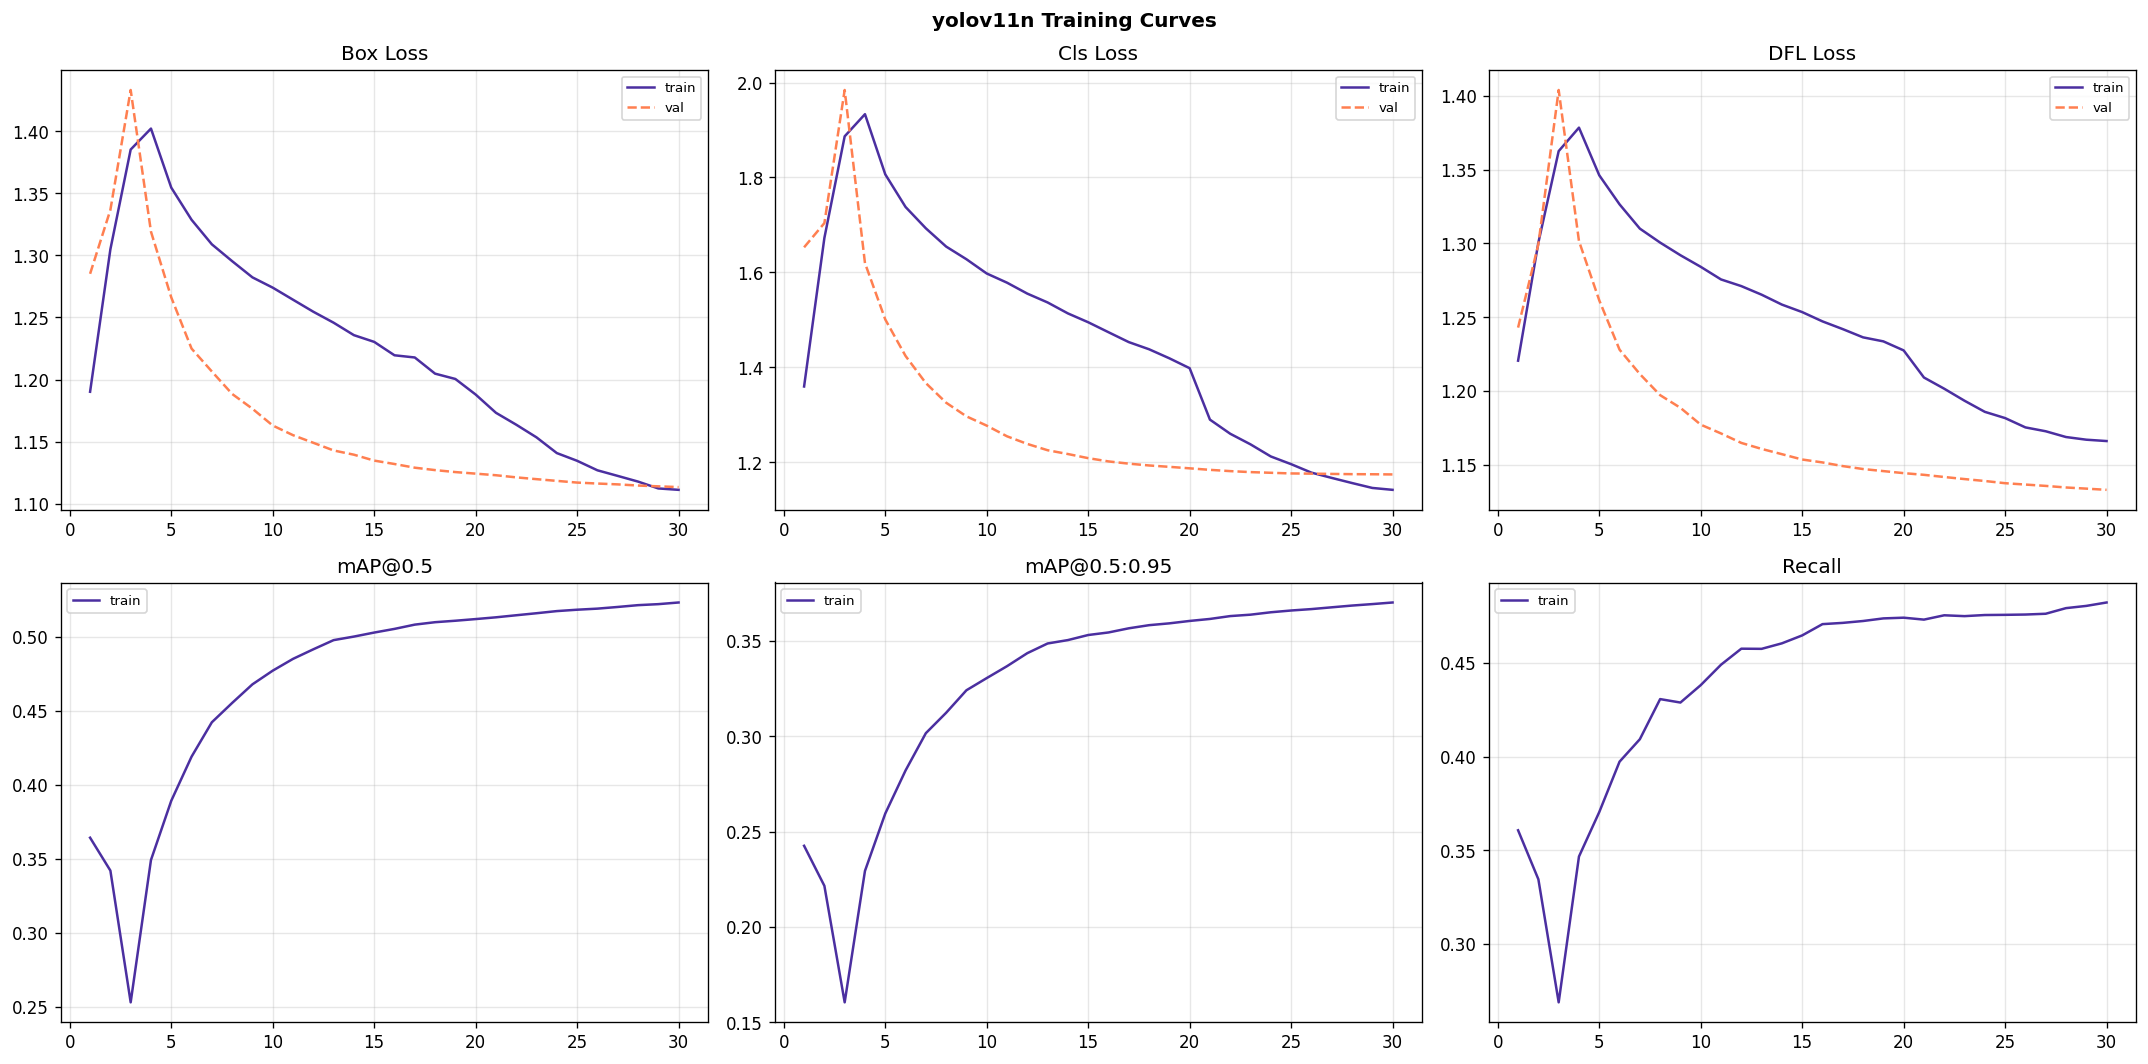

In [27]:
# Training curves
df = pd.read_csv(OUT/'runs'/MODEL_NAME/'results.csv'); df.columns=df.columns.str.strip()
fig, ax = plt.subplots(2,3,figsize=(18,9))
fig.suptitle(f'{MODEL_NAME} Training Curves', fontweight='bold')
specs=[('train/box_loss','val/box_loss','Box Loss'),
       ('train/cls_loss','val/cls_loss','Cls Loss'),
       ('train/dfl_loss','val/dfl_loss','DFL Loss'),
       ('metrics/mAP50(B)',None,'mAP@0.5'),
       ('metrics/mAP50-95(B)',None,'mAP@0.5:0.95'),
       ('metrics/recall(B)',None,'Recall')]
for a,(ct,cv,lb) in zip(ax.flat,specs):
    if ct in df: a.plot(df['epoch'],df[ct],label='train',color='#4B2FA0')
    if cv and cv in df: a.plot(df['epoch'],df[cv],label='val',color='coral',ls='--')
    a.set_title(lb); a.grid(alpha=0.3); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT/f'{MODEL_NAME}_curves.png',dpi=120); plt.show()

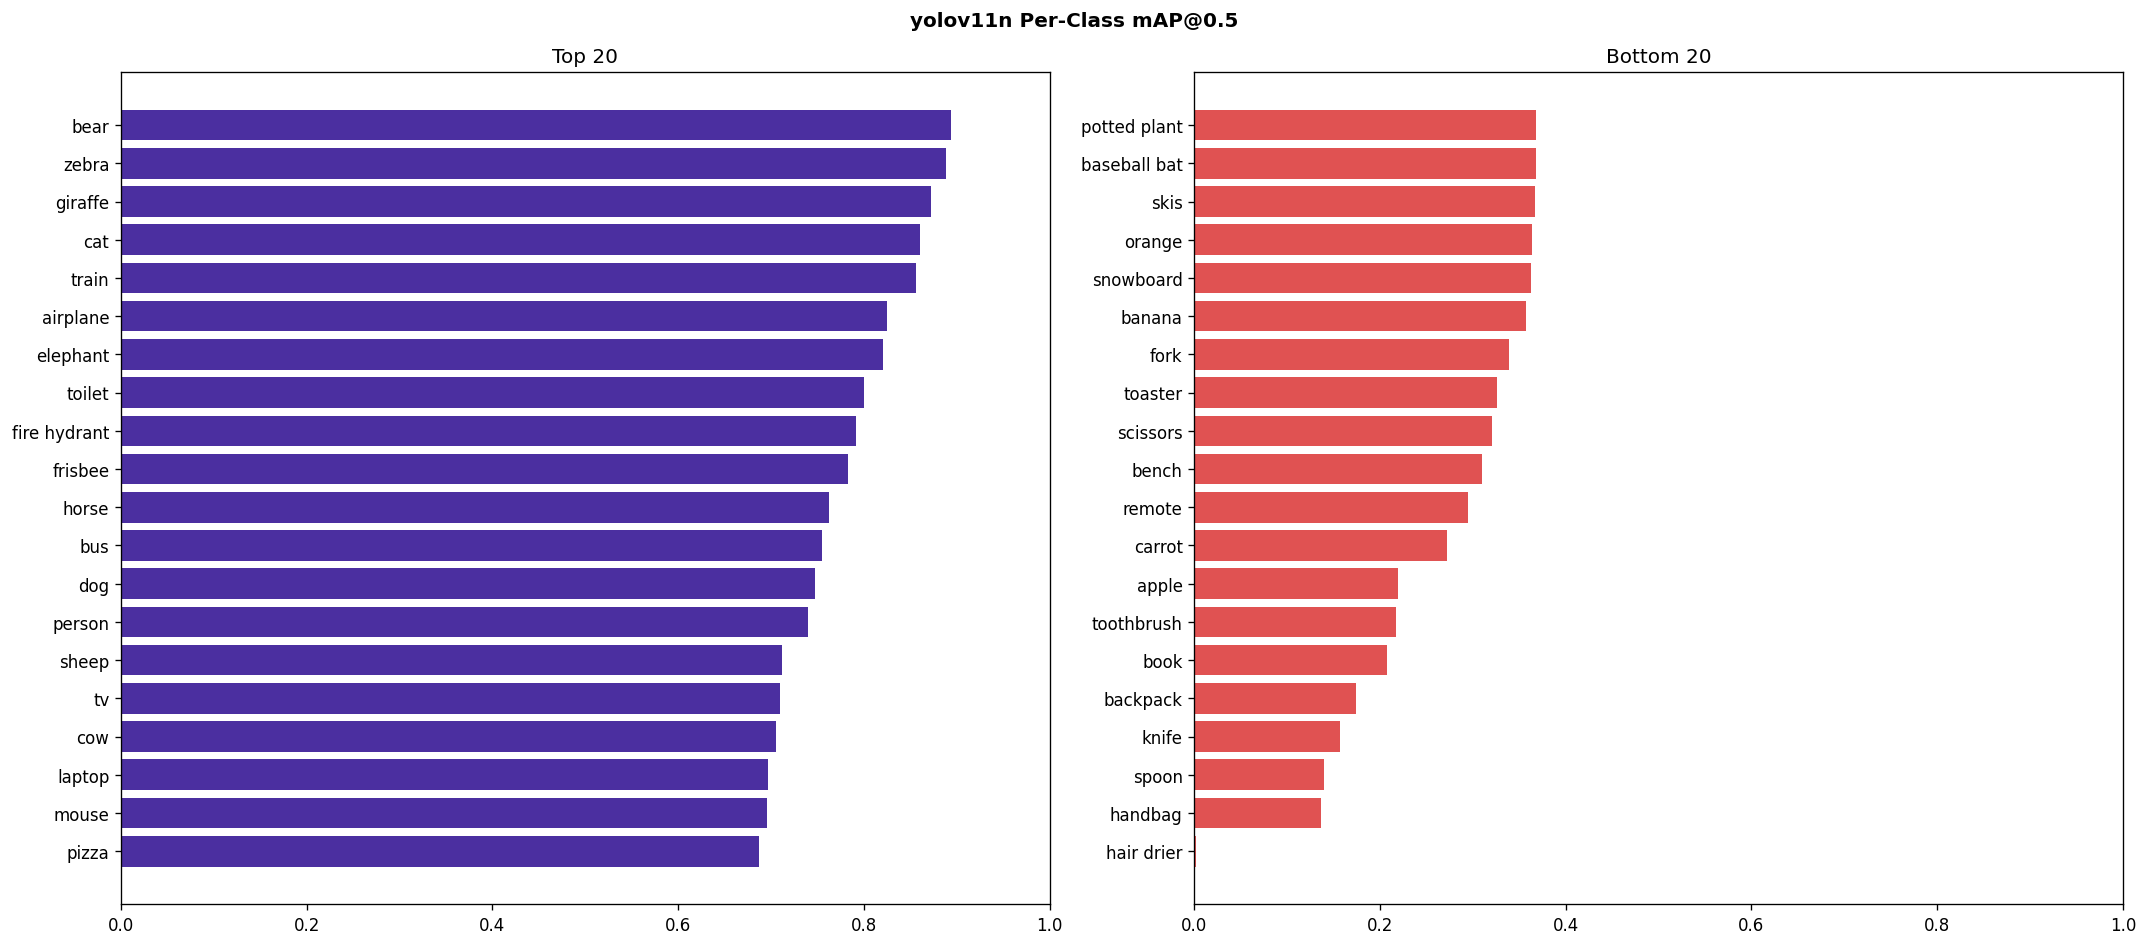

In [28]:
# Per-class mAP (lihat kelas common: person/chair/car penting buat ELIOR)
pc = pd.DataFrame(val_metrics['per_class_ap50'].items(),
                  columns=['class','ap50']).sort_values('ap50')
fig, ax = plt.subplots(1,2,figsize=(18,8))
fig.suptitle(f'{MODEL_NAME} Per-Class mAP@0.5', fontweight='bold')
ax[0].barh(pc['class'][-20:], pc['ap50'][-20:], color='#4B2FA0')
ax[0].set_title('Top 20'); ax[0].set_xlim(0,1)
ax[1].barh(pc['class'][:20], pc['ap50'][:20], color='#E05252')
ax[1].set_title('Bottom 20'); ax[1].set_xlim(0,1)
plt.tight_layout(); plt.savefig(OUT/f'{MODEL_NAME}_perclass.png',dpi=120); plt.show()

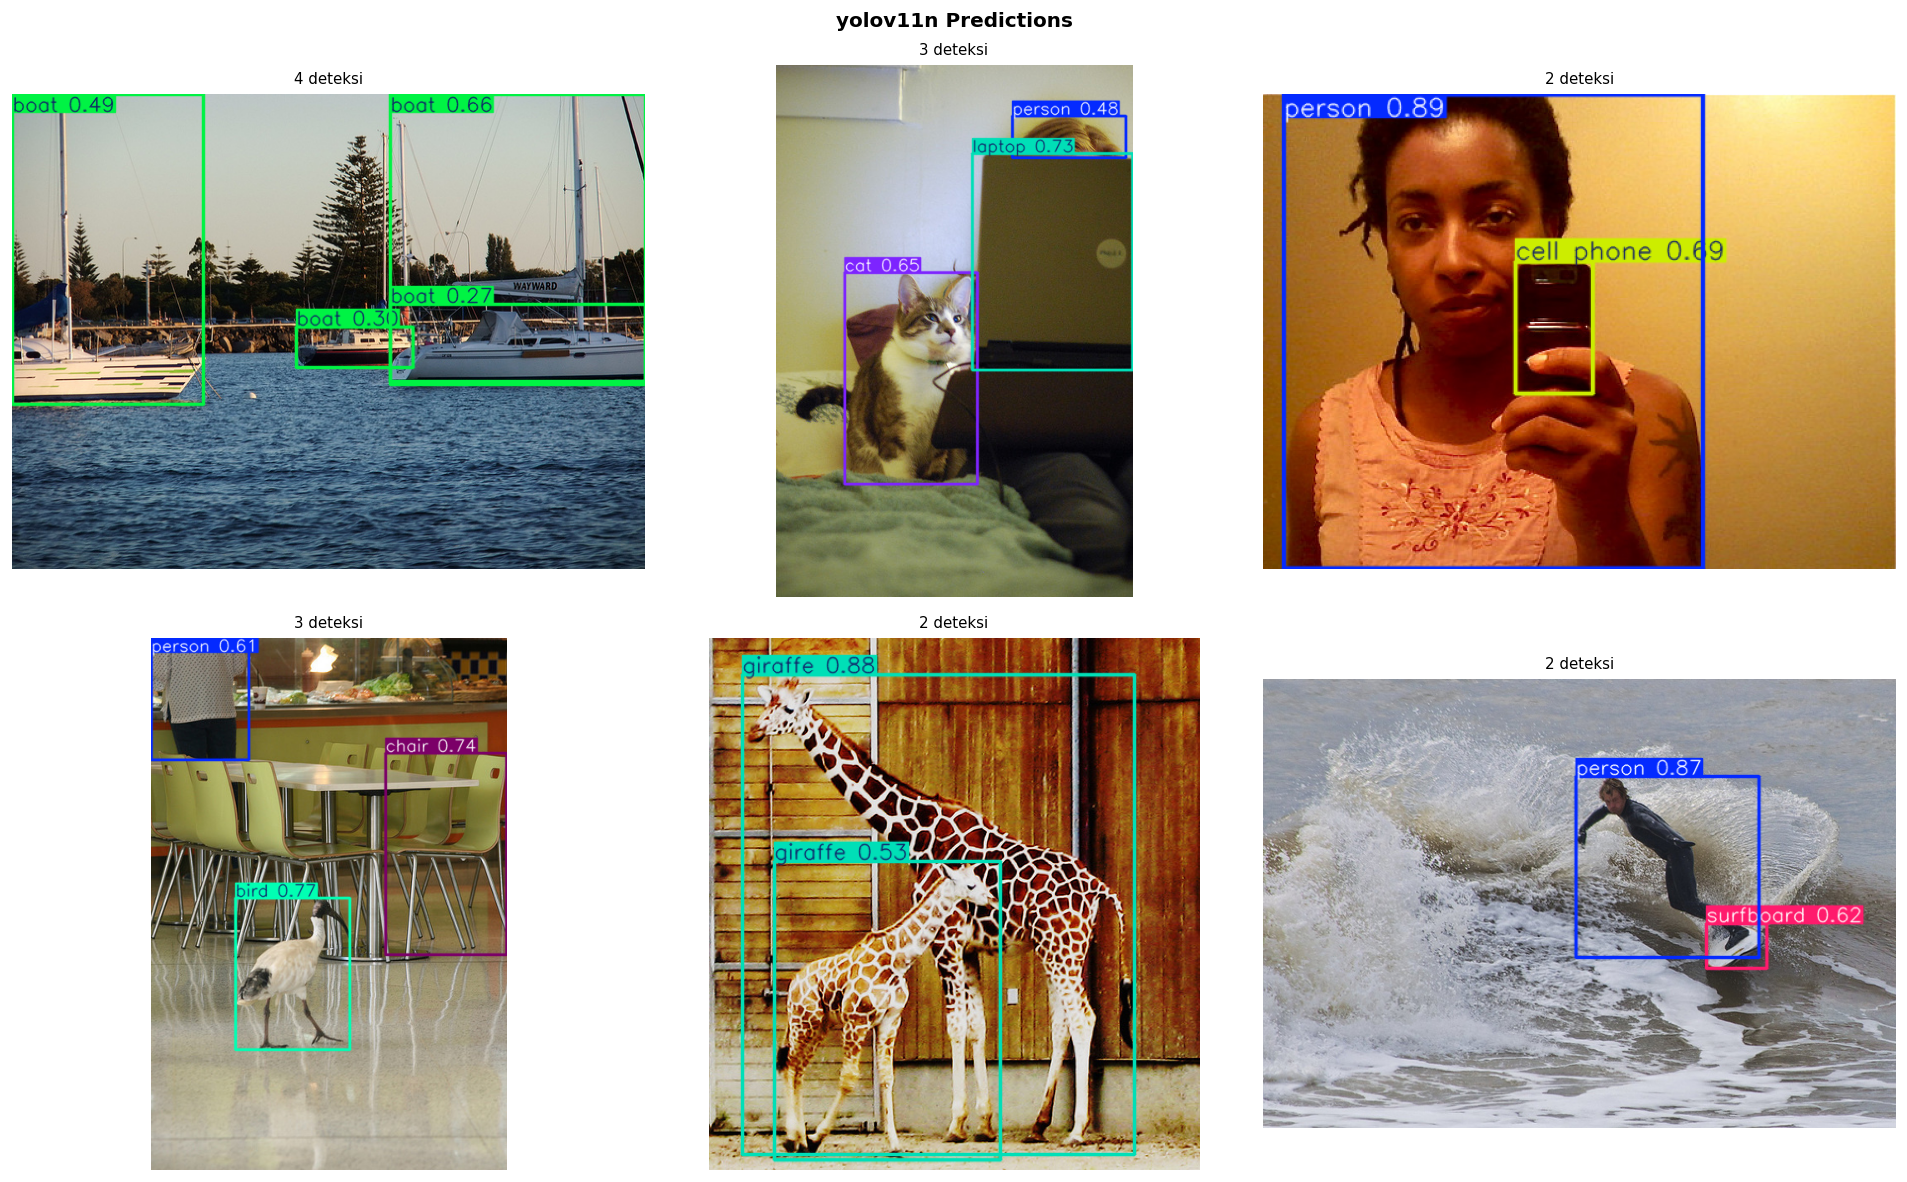

46045

In [29]:
# Visual prediction sample
model = YOLO(str(best))
imgs = random.sample(list(VAL_IMG.glob('*.jpg')), 6)
fig, ax = plt.subplots(2,3,figsize=(16,10))
fig.suptitle(f'{MODEL_NAME} Predictions', fontweight='bold')
for a,p in zip(ax.flat, imgs):
    r = model(str(p), verbose=False)[0]
    a.imshow(r.plot(labels=True, conf=True)[:,:,::-1]); a.axis('off')
    a.set_title(f"{len(r.boxes) if r.boxes else 0} deteksi", fontsize=9)
plt.tight_layout(); plt.savefig(OUT/f'{MODEL_NAME}_predictions.png',dpi=100); plt.show()
del model; torch.cuda.empty_cache(); gc.collect()

## 11 — SAVE METRICS JSON + CHECKPOINT 2 (download v11)
Metrics disimpan ke JSON di disk → dibaca cell comparison (tahan restart kernel).

In [31]:
# copy weight + results ke root, simpan metrics ke JSON
wd = OUT/'runs'/MODEL_NAME/'weights'
for w in wd.glob('*.pt'): shutil.copy2(w, OUT/f'{MODEL_NAME}_{w.name}')
shutil.copy2(OUT/'runs'/MODEL_NAME/'results.csv', OUT/f'{MODEL_NAME}_results.csv')

full = {'val':val_metrics, 'speed':speed_metrics}
with open(OUT/f'{MODEL_NAME}_metrics.json','w') as f: json.dump(full, f, indent=2)
print("Saved:", OUT/f'{MODEL_NAME}_metrics.json')

zip_and_link(
    [f'{MODEL_NAME}_*.pt', f'{MODEL_NAME}_*.csv', f'{MODEL_NAME}_*.png',
     f'{MODEL_NAME}_metrics.json'],
    f'CP2_{MODEL_NAME}_full.zip', label=f'CP2 {MODEL_NAME.upper()}')

Saved: /kaggle/working/yolov11n_metrics.json

  [CP2 YOLOV11N] ZIP: CP2_yolov11n_full.zip (100.7 MB) | 13 file
   + yolov11n_best.pt
   + yolov11n_epoch0.pt
   + yolov11n_epoch10.pt
   + yolov11n_epoch15.pt
   + yolov11n_epoch20.pt
   + yolov11n_epoch25.pt
   + yolov11n_epoch5.pt
   + yolov11n_last.pt
   + yolov11n_results.csv
   + yolov11n_curves.png
   + yolov11n_perclass.png
   + yolov11n_predictions.png
   + yolov11n_metrics.json

  >> Klik link (kalau muncul):


/kaggle/working/CP2_yolov11n_full.zip

  >> Link mati? Save Version -> Output tab -> CP2_yolov11n_full.zip


PosixPath('/kaggle/working/CP2_yolov11n_full.zip')

In [32]:
import shutil, os
from pathlib import Path
from IPython.display import display, FileLink

OUT = Path('/kaggle/working')

# File yang mau dizip
files_to_zip = [
    'yolov11n_best.pt',
    'yolov11n_metrics.json',
    'yolov11n_results.csv',
]

# Zip manual file penting aja (lebih kecil, lebih cepat download)
import zipfile
zip_path = OUT / 'v11n_DOWNLOAD.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in files_to_zip:
        p = OUT / fn
        if p.exists():
            zf.write(p, fn)
            print(f"  + {fn} ({p.stat().st_size/1e6:.1f} MB)")
        else:
            print(f"  MISSING: {fn}")

size = zip_path.stat().st_size / 1e6
print(f"\nZIP: {zip_path.name} ({size:.1f} MB)")
display(FileLink(str(zip_path)))

  + yolov11n_best.pt (5.5 MB)
  + yolov11n_metrics.json (0.0 MB)
  + yolov11n_results.csv (0.0 MB)

ZIP: v11n_DOWNLOAD.zip (5.0 MB)


/kaggle/working/v11n_DOWNLOAD.zip